# Setup and Imports

In [22]:
%load_ext autoreload
%autoreload 2


import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append('../')
from src.models.clustering import build_clustering_matrix
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data.loader import load_raw_data

#Load the data into a DataFrame variable
df = load_raw_data()

df.head()
X_cluster_scaled = build_clustering_matrix(df)

print(f"Clustering matrix shape: {X_cluster_scaled.shape}")
display(X_cluster_scaled.head())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Successfully located and loaded raw data from: data/raw/agent_tool_tasks.csv
Clustering matrix shape: (3491, 18)


,aspect_coverage_ratio,aspect_overlap_count,aspect_mismatch_count,query_tool_token_jaccard,query_tool_action_overlap,query_word_count,query_multi_intent_score,query_specificity_score,query_unique_token_ratio,num_available_tools,total_params,total_required_params,schema_rigidity_score,param_type_diversity,risky_tool_action_count,query_sensitive_data_signal,query_code_signal,query_temporal_signal
0,-0.626371,-0.598619,-0.482539,-0.891187,-0.613078,-0.414591,-0.484466,-0.209516,0.638576,-0.718585,-0.951564,-0.786273,1.530793,-1.175999,-0.492574,-0.265576,-0.303814,-0.343272
1,-0.626371,-0.598619,-0.482539,-0.891187,-0.613078,-0.355231,-0.484466,-0.209516,0.638576,-0.718585,-0.828562,-0.786273,-0.186265,-1.175999,-0.492574,-0.265576,-0.303814,-0.343272
2,-0.626371,-0.598619,0.992542,0.097655,1.376007,-0.157367,0.123905,-0.083249,0.638576,-0.718585,-0.828562,-0.786273,-0.186265,-1.175999,-0.492574,-0.265576,3.291489,-0.343272
3,-0.626371,-0.598619,-0.482539,0.272156,1.376007,-0.177154,-0.484466,-0.167427,0.638576,0.761404,0.155452,0.493987,-0.137206,1.874085,-0.492574,-0.265576,-0.303814,-0.343272
4,0.150736,1.218581,2.467623,0.168286,1.376007,0.713235,3.774132,0.253462,-1.604270,-0.225256,-0.582559,-0.359519,0.856235,0.857390,-0.492574,-0.265576,-0.303814,2.913145


## Clustering Algorithms

In [23]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore') # Suppress K-Means memory leak warnings on Windows

k_values = range(2, 11) 
agg_configs = [
    ('ward', 'euclidean'),
    ('complete', 'euclidean'),
    ('complete', 'manhattan'),
    ('average', 'euclidean'),
    ('average', 'manhattan')
]

kmeans_wcss = []
kmeans_silhouette = []
agg_silhouette = {f"{link} / {dist}": [] for link, dist in agg_configs}

print("Running K-Means...")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)
    kmeans_wcss.append(kmeans.inertia_)
    kmeans_silhouette.append(silhouette_score(X_cluster_scaled, labels))

print("Running Agglomerative Clustering (This may take a minute)...")
for link, dist in agg_configs:
    config_name = f"{link} / {dist}"
    for k in k_values:
        agg = AgglomerativeClustering(n_clusters=k, linkage=link, metric=dist)
        labels = agg.fit_predict(X_cluster_scaled)
        agg_silhouette[config_name].append(silhouette_score(X_cluster_scaled, labels))

Running K-Means...
Running Agglomerative Clustering (This may take a minute)...


## Visualizations

Generating visualizations...


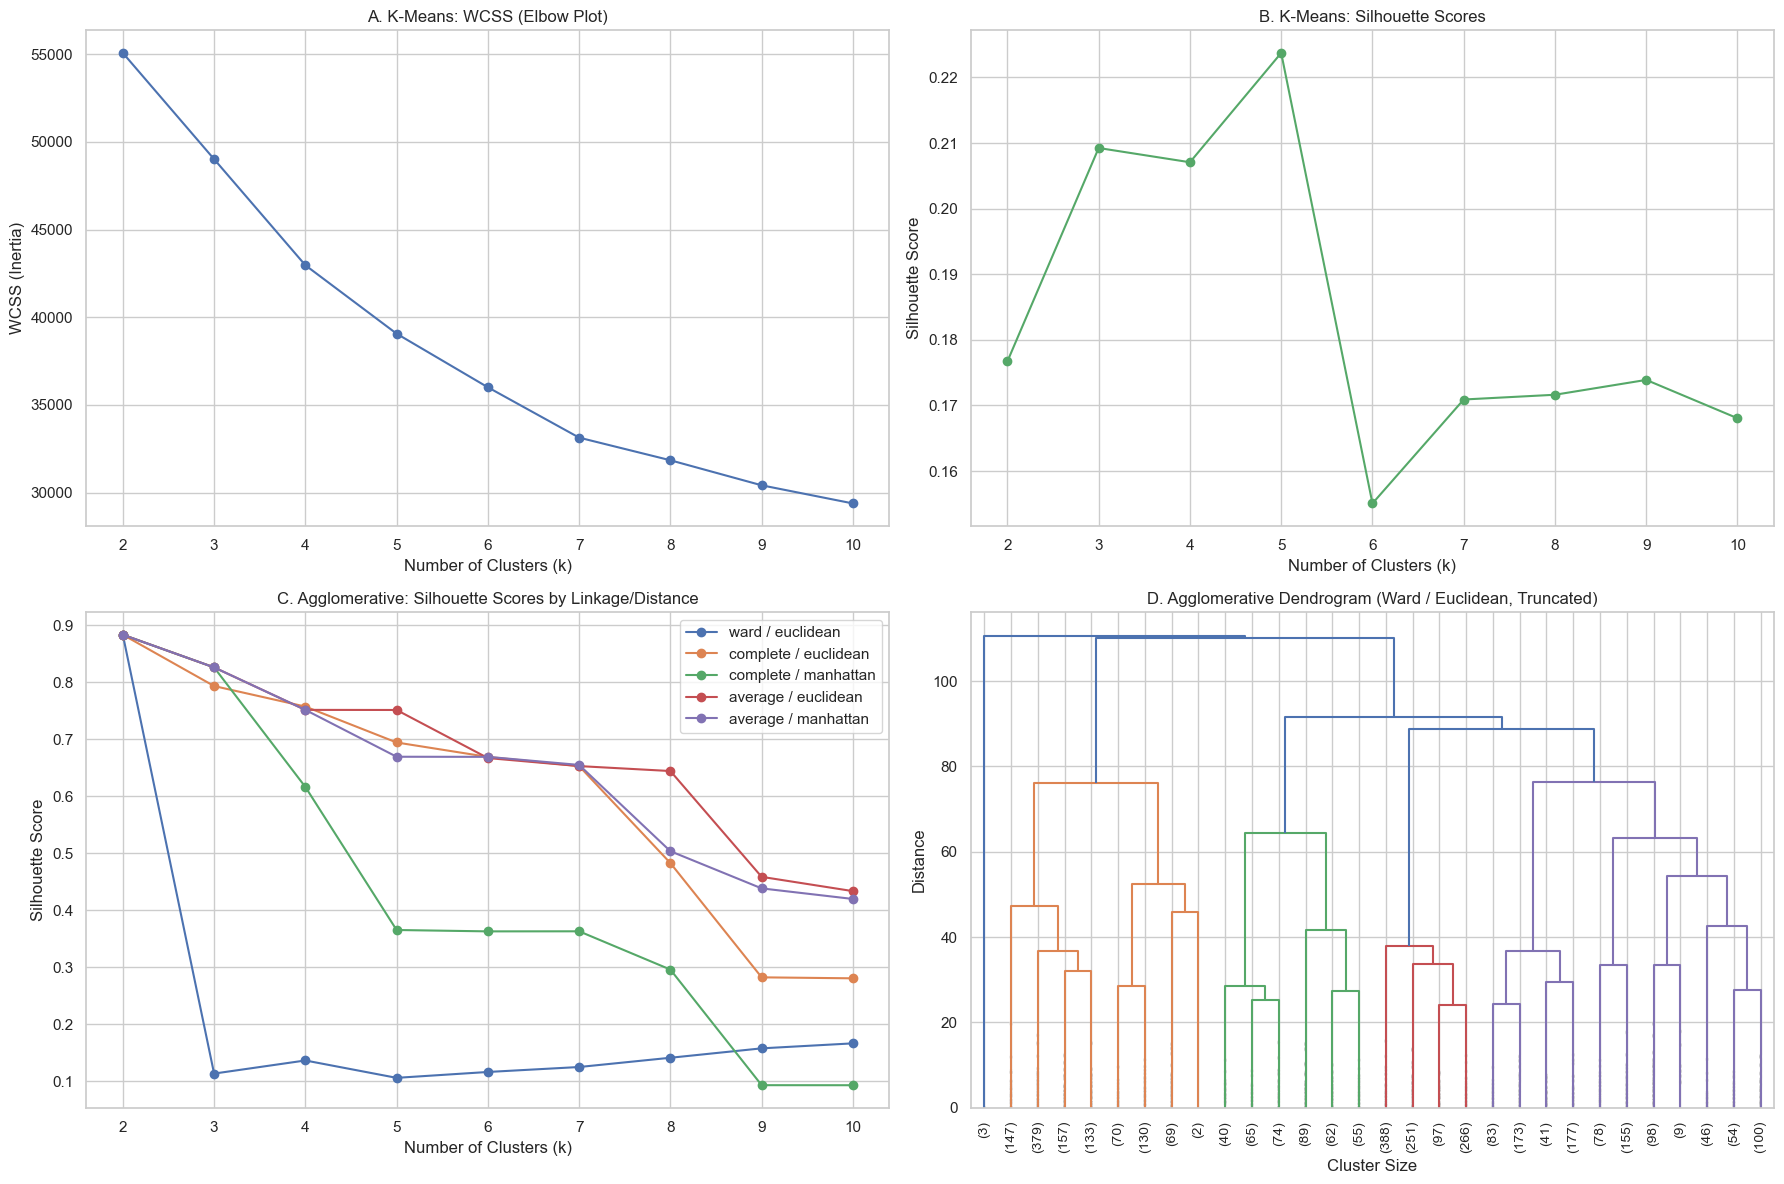

In [24]:
print("Generating visualizations...")

fig = plt.figure(figsize=(18, 12))
sns.set_theme(style="whitegrid")

# Plot A: K-Means WCSS
ax1 = plt.subplot(2, 2, 1)
ax1.plot(k_values, kmeans_wcss, marker='o', color='b')
ax1.set_title('A. K-Means: WCSS (Elbow Plot)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)')

# Plot B: K-Means Silhouette Scores
ax2 = plt.subplot(2, 2, 2)
ax2.plot(k_values, kmeans_silhouette, marker='o', color='g')
ax2.set_title('B. K-Means: Silhouette Scores')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')

# Plot C: Agglomerative Silhouette Comparison
ax3 = plt.subplot(2, 2, 3)
for config_name, scores in agg_silhouette.items():
    ax3.plot(k_values, scores, marker='o', label=config_name)
ax3.set_title('C. Agglomerative: Silhouette Scores by Linkage/Distance')
ax3.set_xlabel('Number of Clusters (k)')
ax3.set_ylabel('Silhouette Score')
ax3.legend()

# Plot D: Dendrogram 
ax4 = plt.subplot(2, 2, 4)
Z = linkage(X_cluster_scaled, method='ward', metric='euclidean')
dendrogram(Z, truncate_mode='lastp', p=30, ax=ax4, leaf_rotation=90, show_contracted=True)
ax4.set_title('D. Agglomerative Dendrogram (Ward / Euclidean, Truncated)')
ax4.set_xlabel('Cluster Size')
ax4.set_ylabel('Distance')

plt.tight_layout()
plt.show()

### interptation:
By cross-referencing multiple validation metrics, K = 5 was selected as the optimal number of clusters. For K-Means, this is strongly supported by the Silhouette Plot (Plot B), which achieves a clear global maximum at K = 5. This is corroborated by the WCSS Elbow Plot (Plot A), where the rate of inertia decrease visibly flattens after 5 clusters.For Agglomerative Clustering, I observed a common metric divergence. While Average Linkage (Plot C) yielded a mathematically higher Silhouette score, this often occurs artificially when an algorithm isolates a few extreme outliers into practically useless, microscopic clusters. Instead, Ward Linkage with Euclidean distance was prioritized. While its Silhouette score is lower due to overlapping cluster boundaries, it produces practically sized, interpretable groups. This structural balance is perfectly validated by the Dendrogram (Plot D), which naturally yields 5 highly distinct, healthy branches when cut at a distance threshold of ~70.

# Cluster Interpretation

In [26]:
from src.pipelines.preprocessing import preprocess_data
from src.models.classifiers import get_random_forest_model
import numpy as np

print("Fitting Final K-Means Model (k=5)...")
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
# Add cluster labels to the FULL original dataframe
df['Cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

print("Generating Random Forest Predictions on Test Set for Error Analysis...")
X_train_p, X_val_p, X_test_p, y_train, y_val, y_test = preprocess_data(df)

rf = get_random_forest_model()
rf.fit(X_train_p, y_train)

test_predictions = rf.predict(X_test_p)

# Create a clean dataframe just for the Test Set Error Analysis
df_errors = pd.DataFrame(index=y_test.index)
df_errors['True_Label'] = y_test
df_errors['Prediction'] = test_predictions

# Map exactly what kind of error occurred
df_errors['Error_Type'] = 'Correct'
df_errors.loc[(df_errors['True_Label'] == 0) & (df_errors['Prediction'] == 1), 'Error_Type'] = 'False Positive'
df_errors.loc[(df_errors['True_Label'] == 1) & (df_errors['Prediction'] == 0), 'Error_Type'] = 'False Negative'

df_errors['Cluster'] = df.loc[df_errors.index, 'Cluster']

print("\n" + "="*35)
print("CLUSTER INTERPRETATION PROFILES")
print("="*35)

for cluster_id in range(5):
    # Overall cluster stats (from the whole dataset)
    cluster_full_data = df[df['Cluster'] == cluster_id]
    # Error stats (strictly from the test set)
    cluster_error_data = df_errors[df_errors['Cluster'] == cluster_id]
    
    size = len(cluster_full_data)
    
    answer_rate = cluster_full_data['can_answer'].mean() * 100
    top_domain = cluster_full_data['task_domain'].mode()[0]
    top_complexity = cluster_full_data['task_complexity'].mode()[0]
    medians = cluster_full_data[['num_available_tools', 'query_word_count', 'aspect_coverage_ratio']].median()
    
    if len(cluster_error_data) > 0:
        error_counts = cluster_error_data['Error_Type'].value_counts(normalize=True) * 100
        fp_rate = error_counts.get('False Positive', 0.0)
        fn_rate = error_counts.get('False Negative', 0.0)
    else:
        fp_rate, fn_rate = 0.0, 0.0
        
    print(f"\n================ CLUSTER {cluster_id} ================")
    print(f"Size:          {size} rows ({size/len(df)*100:.1f}% of dataset)")
    print("\n--- RAW DATA ---")
    print(f"Answer Rate:   {answer_rate:.1f}%")
    print(f"Top Category:  Domain = '{top_domain}' | Complexity = '{top_complexity}'")
    print(f"Medians:       Tools = {medians['num_available_tools']:.0f} | Words = {medians['query_word_count']:.0f} | Aspect Coverage = {medians['aspect_coverage_ratio']:.2f}")
    
    print("\n--- RANDOM FOREST EVALUATION ---")
    print(f"Test Errors:   {fp_rate:.1f}% False Positives | {fn_rate:.1f}% False Negatives")

Fitting Final K-Means Model (k=5)...
Generating Random Forest Predictions on Test Set for Error Analysis...

CLUSTER INTERPRETATION PROFILES

================ CLUSTER 0 ================
Size:          313 rows (9.0% of dataset)

--- RAW DATA ---
Answer Rate:   46.0%
Top Category:  Domain = 'other' | Complexity = 'low'
Medians:       Tools = 1 | Words = 22 | Aspect Coverage = 0.00

--- RANDOM FOREST EVALUATION ---
Test Errors:   9.3% False Positives | 4.7% False Negatives

================ CLUSTER 1 ================
Size:          3 rows (0.1% of dataset)

--- RAW DATA ---
Answer Rate:   0.0%
Top Category:  Domain = 'vision' | Complexity = 'high'
Medians:       Tools = 1 | Words = 1436 | Aspect Coverage = 0.00

--- RANDOM FOREST EVALUATION ---
Test Errors:   0.0% False Positives | 0.0% False Negatives

================ CLUSTER 2 ================
Size:          416 rows (11.9% of dataset)

--- RAW DATA ---
Answer Rate:   76.0%
Top Category:  Domain = 'travel' | Complexity = 'high'
Median

By cross-referencing the unsupervised K-Means clusters with the predictions from the supervised Random Forest model, we can distinctly profile the AI agent's operational environments and identify exactly where it succeeds and fails.

- Cluster 0: The Ambiguous Long Queries
This cluster represents wordy, edge-case prompts (median 22 words) that lack a clear domain. Because the queries are long but the tool aspect coverage is low, the Random Forest struggles to find clear thresholds, resulting in the highest False Positive rate (9.3%). The model frequently hallucinates that a tool is needed simply because the user typed a lot of text.

- Cluster 1: The Massive Outliers (Pure True Negatives)
This cluster contains severe anomalies, characterized by an absurd median word count of 1,436. Because the input is so overwhelming and irrelevant to the available tools, the Answer Rate is 0.0%. Crucially, the Random Forest handles these perfectly, resulting in 100% True Negatives with zero errors.

- Cluster 2: The Complex Multi-Tool Traps
Defined by high-complexity "Travel" tasks, this cluster offers the agent a massive arsenal of tools (median 5). The abundance of tools confuses the Random Forest into an aggressive posture; it assumes that with so many tools available, one of them must be relevant. This leads to a high False Positive rate (8.2%), as the model falls into the trap of over-assigning tools to complex queries.

- Cluster 3: The Clear-Cut True Positives
This is the ultimate "Answer" cluster, dominated by the Math domain. With perfect aspect coverage and a ~90% Answer Rate, the features here almost universally guarantee can_answer = 1. Because the signal is so strong, there are 0.0% False Negatives—the model never misses a valid tool opportunity. However, because the model learned to trust these features so heavily, it occasionally over-qualifies similarities, causing a 7.1% False Positive rate.

- Cluster 4: The Simple Baseline
Containing the vast majority of the dataset (56%), this cluster represents standard, everyday operations. The queries are short (median 12 words), complexity is low, and usually, only 1 tool is available. Because this is the model's most balanced and familiar territory, the error rates are low and perfectly symmetrical (~5.3% for both FP and FN).